# `GEA` tutorial: T2D cohort in mouse data from CELLxGENE

## Getting data from CELLxGENE

In [1]:
import cellxgene_census
import scanpy as sc
from scipy.sparse import csr_matrix
import re

In [2]:
with cellxgene_census.open_soma() as census:

    adata = cellxgene_census.get_anndata(
        census=census,
        organism="Mus musculus",
        obs_value_filter=(
            "tissue_type == 'tissue' "
            "and tissue == 'islet of Langerhans' "  # specific tissue type located on pancreas
            "and is_primary_data == True"
        ),
    )

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
def process_tabula_dataset(adata, species_name, cell_type_number_filter=350):
    print(f"\n--- Processing {species_name} ---")

    print(f"Initial cells: {adata.n_obs}, Initial genes: {adata.n_vars}")

    # 1. Map 10x 3' Assay safely
    adata = adata[
        adata.obs["assay"].isin({"10x 3' v2", "10x 3' v3"})
    ].copy()
    print(f"Cells remaining after 10x 3' assay filter: {adata.n_obs}")

    # 2. Filter by Cell Type Count (> 350 cells per cell type)
    if cell_type_number_filter > 0:
        vc = adata.obs["cell_type"].value_counts()
        valid_cell_types = vc[vc > cell_type_number_filter].index
        adata = adata[adata.obs["cell_type"].isin(valid_cell_types)].copy()
        print(f"Cells remaining after cell type count filter: {adata.n_obs}")

    # 3. Retain protein-coding genes only
    protein_coding_mask = (
        adata.var["feature_type"] == "protein_coding"
    )  # feature_type in sapiens and muris, check for others
    adata = adata[:, protein_coding_mask].copy()
    print(f"Genes remaining after protein-coding filter: {adata.n_vars}")

    # 4. Filter cells with less than 500 genes expressed
    sc.pp.filter_cells(adata, min_genes=500)
    print(f"Cells remaining after gene count filter: {adata.n_obs}")

    # 5. Filter genes expressed in less than 1000 cells
    sc.pp.filter_genes(adata, min_cells=1000)
    print(f"Genes remaining after cell count filter: {adata.n_vars}")

    print("\n--- Final Dataset Summary ---\n")

    print(f"Final cells: {adata.n_obs}, Final genes: {adata.n_vars}")

    return adata

In [4]:
adata_filter = process_tabula_dataset(adata, species_name="Mouse pancreatic data")


--- Processing Mouse pancreatic data ---
Initial cells: 264235, Initial genes: 53384


Cells remaining after 10x 3' assay filter: 264235


Cells remaining after cell type count filter: 263991


Genes remaining after protein-coding filter: 21677


Cells remaining after gene count filter: 261636


Genes remaining after cell count filter: 14330

--- Final Dataset Summary ---

Final cells: 261636, Final genes: 14330


In [5]:
keep_tissue = ["type B pancreatic cell", "pancreatic A cell", "pancreatic D cell", "pancreatic stellate cell", "endothelial cell", "pancreatic ductal cell", "pancreatic PP cell"]
keep_phenotype = ["normal", "type 2 diabetes mellitus"]

adata_filter_cells = adata_filter[adata_filter.obs["cell_type"].isin(keep_tissue) & adata_filter.obs["disease"].isin(keep_phenotype)].copy()

adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()

/tmp/ipykernel_3029503/710005710.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()


cell_type                 disease                 
endothelial cell          normal                       4383
                          type 2 diabetes mellitus     3886
pancreatic A cell         normal                      16200
                          type 2 diabetes mellitus    15711
pancreatic D cell         normal                       7354
                          type 2 diabetes mellitus    10896
pancreatic PP cell        normal                       2257
                          type 2 diabetes mellitus     3291
pancreatic ductal cell    normal                       2007
                          type 2 diabetes mellitus     3100
pancreatic stellate cell  normal                       5103
                          type 2 diabetes mellitus     4809
type B pancreatic cell    normal                      54253
                          type 2 diabetes mellitus    32779
dtype: int64

## Pseudobulk aggregation — `donor_id` × `cell_type` × `disease`

The GEA pipeline (LIONESS + PPI prior) treats **one sample = one graph**, and LIONESS is a
**bulk** method: it infers a sample-specific network as a leave-one-out perturbation of a
Pearson gene–gene co-expression matrix. Applying it per *cell* is both statistically wrong
(scRNA-seq is sparse/zero-inflated, and a single cell barely perturbs a correlation over
10⁵ cells) and computationally infeasible (~166 k graphs, hundreds of GB).

The right unit of analysis is the **pseudobulk profile**: sum raw counts across all cells of a
given `(donor, cell_type, disease)` group. This yields ~200 robust, bulk-like profiles —
the same regime as the 303-sample IBD cohort — and preserves **both axes of variation**:
disease becomes the graph label, cell type a covariate (or the LIONESS grouping variable).
Note that in this cohort **disease is a donor-level property** (a donor is either normal or
T2D), so `× disease` mainly serves as a label; the profile count is driven by donors × cell types.

In [6]:
import numpy as np, pandas as pd
from scipy.sparse import csr_matrix

GROUP_KEYS = ["donor_id", "cell_type", "disease"]
MIN_CELLS  = 20        # pseudobulks below this are statistically unreliable → dropped

obs = adata_filter_cells.obs.copy()
for k in GROUP_KEYS:
    obs[k] = obs[k].astype(str)

# One pseudobulk = SUM of raw counts over every cell in a (donor, cell_type, disease) group.
# Implemented as a sparse group-indicator matmul: indicatorᵀ · X  →  [groups × genes].
labels = obs[GROUP_KEYS].agg(" | ".join, axis=1)
codes, uniques = pd.factorize(labels)
ind = csr_matrix((np.ones(adata_filter_cells.n_obs),
                  (np.arange(adata_filter_cells.n_obs), codes)),
                 shape=(adata_filter_cells.n_obs, len(uniques)))
pb      = np.asarray((ind.T @ adata_filter_cells.X).todense())   # [groups × genes] summed counts
n_cells = np.asarray(ind.sum(axis=0)).ravel().astype(int)

# Mouse Ensembl IDs (ENSMUSG…) as the gene index — required by the downstream STRING /
# embedding steps (remember to query STRING with species=10090, mygene species='mouse').
var      = adata_filter_cells.var
gene_ids = (var["feature_id"] if "feature_id" in var.columns else var.index).astype(str).values

pb_meta = pd.DataFrame([u.split(" | ") for u in uniques], columns=GROUP_KEYS)
pb_meta["n_cells"]   = n_cells
pb_meta["sample_id"] = (pb_meta["donor_id"] + "|"
                        + pb_meta["cell_type"].str.replace(" ", "_") + "|"
                        + pb_meta["disease"].str.replace(" ", "_"))

keep = pb_meta["n_cells"].values >= MIN_CELLS
pb_counts = pd.DataFrame(pb[keep].T, index=gene_ids,
                         columns=pb_meta.loc[keep, "sample_id"].values)
pb_counts.index.name = "Geneid"
pb_meta = pb_meta.loc[keep].reset_index(drop=True)

# Persist in the same layout as the IBD tutorial (genes × samples counts + metadata table),
# so the existing gea loaders / LIONESS pipeline can consume it unchanged.
pb_counts.to_csv("data/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t")
pb_meta.to_csv("data/tutorial-t2d-pseudobulk-metadata.csv", index=False)

print(f"Pseudobulk matrix : {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")
print(f"Donors            : {pb_meta['donor_id'].nunique()}  "
      f"(dropped {int((~keep).sum())} groups with <{MIN_CELLS} cells)")
pb_meta.head()

Pseudobulk matrix : 14330 genes × 196 samples
Donors            : 34  (dropped 33 groups with <20 cells)


,donor_id,cell_type,disease,n_cells,sample_id
0,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,pancreatic stellate cell,normal,1425,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...
1,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2,pancreatic PP cell,type 2 diabetes mellitus,312,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2...
2,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,pancreatic D cell,type 2 diabetes mellitus,199,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...
3,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5,pancreatic PP cell,type 2 diabetes mellitus,767,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5...
4,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,type B pancreatic cell,type 2 diabetes mellitus,2205,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...


### Composition — how many profiles per cell type × disease?

Pseudobulk profiles per cell type × disease:

disease                   normal  type 2 diabetes mellitus
cell_type                                                 
endothelial cell              13                        12
pancreatic A cell             22                        12
pancreatic D cell             22                        12
pancreatic PP cell            17                        12
pancreatic ductal cell         8                        10
pancreatic stellate cell      10                        12
type B pancreatic cell        22                        12

Total profiles: 196 | donors: 34 (normal 22, T2D 12)


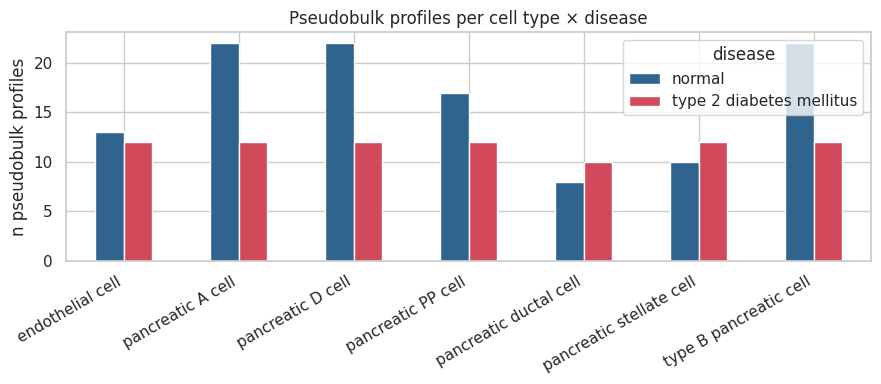

In [7]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
DPAL = {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"}

comp = pd.crosstab(pb_meta["cell_type"], pb_meta["disease"])
print("Pseudobulk profiles per cell type × disease:\n")
print(comp.to_string())
n_norm = pb_meta[pb_meta.disease == "normal"]["donor_id"].nunique()
n_t2d  = pb_meta[pb_meta.disease != "normal"]["donor_id"].nunique()
print(f"\nTotal profiles: {len(pb_meta)} | donors: {pb_meta['donor_id'].nunique()} "
      f"(normal {n_norm}, T2D {n_t2d})")

ax = comp.plot(kind="bar", figsize=(9, 4),
               color=[DPAL.get(c, "#888") for c in comp.columns])
ax.set_ylabel("n pseudobulk profiles"); ax.set_xlabel("")
ax.set_title("Pseudobulk profiles per cell type × disease")
plt.xticks(rotation=30, ha="right"); plt.legend(title="disease")
plt.tight_layout(); plt.show()

### Per-profile QC — cells aggregated, library size, gene detection

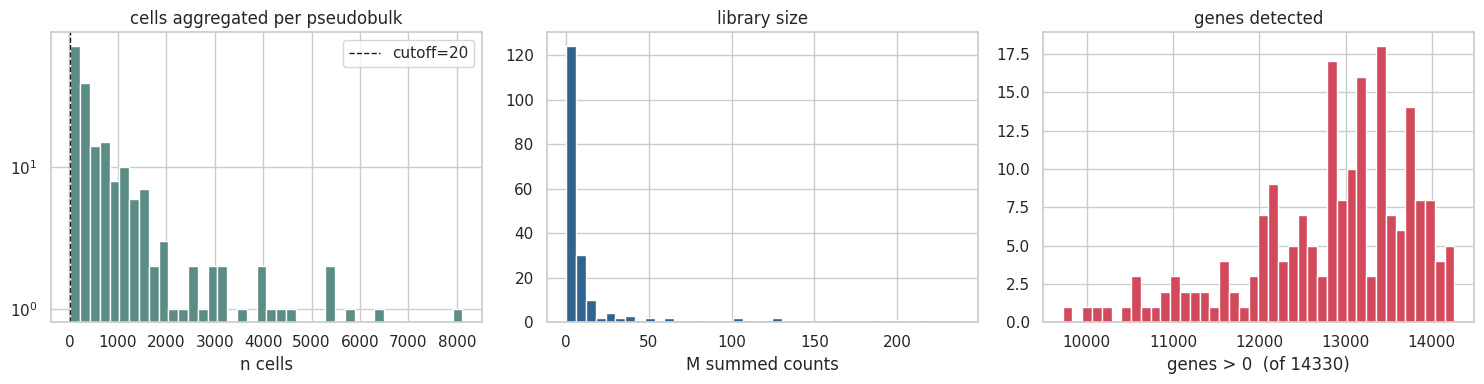

cells per pseudobulk:
 count     196.0
mean      846.0
std      1271.0
min        23.0
25%       136.0
50%       319.0
75%       972.0
max      8114.0


In [8]:
lib       = pb_counts.sum(axis=0)
genes_det = (pb_counts > 0).sum(axis=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(pb_meta["n_cells"], bins=40, color="#5b8c85"); ax[0].set_yscale("log")
ax[0].axvline(MIN_CELLS, color="k", ls="--", lw=1, label=f"cutoff={MIN_CELLS}")
ax[0].set_title("cells aggregated per pseudobulk"); ax[0].set_xlabel("n cells"); ax[0].legend()
ax[1].hist(lib/1e6, bins=40, color="#30638e")
ax[1].set_title("library size"); ax[1].set_xlabel("M summed counts")
ax[2].hist(genes_det, bins=40, color="#d1495b")
ax[2].set_title("genes detected"); ax[2].set_xlabel(f"genes > 0  (of {pb_counts.shape[0]})")
plt.tight_layout(); plt.show()

print("cells per pseudobulk:\n", pb_meta["n_cells"].describe().round(0).to_string())

### The two axes of variation: cell type vs disease

Your stated concern is that this dataset carries **two** structured sources of variation.
A PCA of the pseudobulk profiles makes them visible, and a simple variance partition
quantifies how much of the expression variance each factor explains.

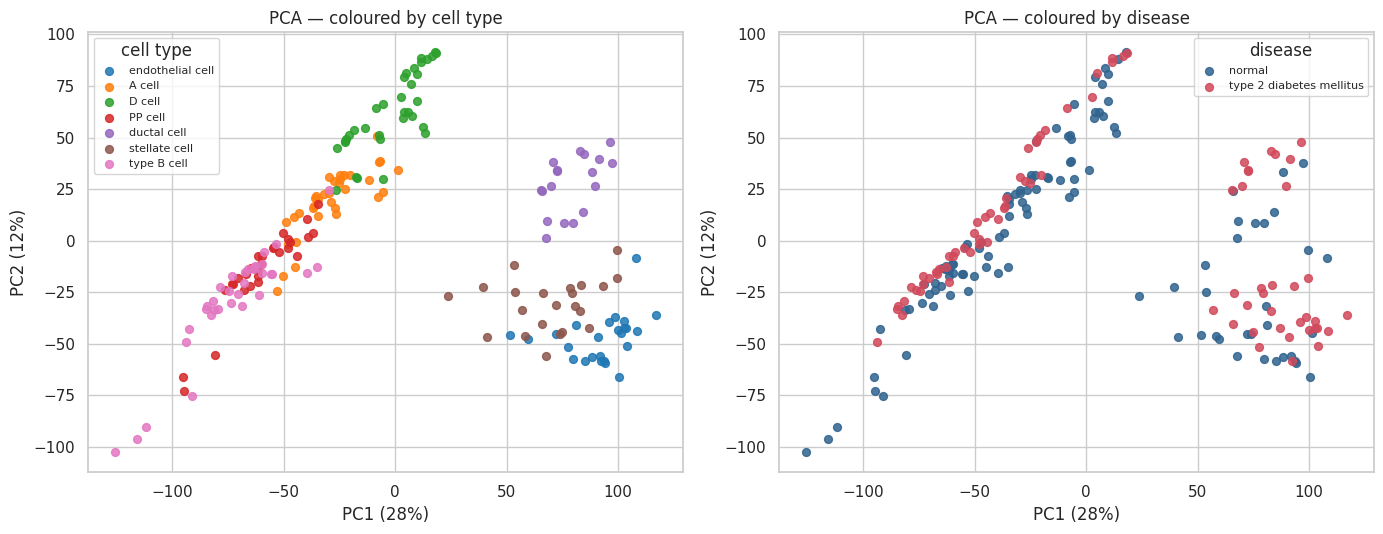

In [9]:
from gea.preprocessing import normalize_counts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

norm = normalize_counts(pb_counts)                     # samples × genes, log2(CPM+1)
m    = pb_meta.set_index("sample_id").loc[norm.index]  # align metadata to matrix rows
Xs   = StandardScaler().fit_transform(norm.values)
pca  = PCA(n_components=15, random_state=42).fit(Xs)
XP   = pca.transform(Xs)

CPAL = dict(zip(sorted(m["cell_type"].unique()), sns.color_palette("tab10")))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for ct in sorted(m["cell_type"].unique()):
    s = m["cell_type"].values == ct
    ax[0].scatter(XP[s,0], XP[s,1], s=32, alpha=.85, color=CPAL[ct],
                  label=ct.replace("pancreatic ", ""))
ax[0].legend(fontsize=8, title="cell type"); ax[0].set_title("PCA — coloured by cell type")
for d in m["disease"].unique():
    s = m["disease"].values == d
    ax[1].scatter(XP[s,0], XP[s,1], s=32, alpha=.85, color=DPAL[d], label=d)
ax[1].legend(fontsize=8, title="disease"); ax[1].set_title("PCA — coloured by disease")
for a in ax:
    a.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
    a.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.tight_layout(); plt.show()

In [ ]:
from umap import UMAP

# Compute UMAP embedding from standardized PCA space
umap = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
XU = umap.fit_transform(Xs)

# Plot UMAP with same color schemes
CPAL = dict(zip(sorted(m["cell_type"].unique()), sns.color_palette("tab10")))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for ct in sorted(m["cell_type"].unique()):
    s = m["cell_type"].values == ct
    ax[0].scatter(XU[s,0], XU[s,1], s=32, alpha=.85, color=CPAL[ct],
                  label=ct.replace("pancreatic ", ""))
ax[0].legend(fontsize=8, title="cell type"); ax[0].set_title("UMAP — coloured by cell type")
for d in m["disease"].unique():
    s = m["disease"].values == d
    ax[1].scatter(XU[s,0], XU[s,1], s=32, alpha=.85, color=DPAL[d], label=d)
ax[1].legend(fontsize=8, title="disease"); ax[1].set_title("UMAP — coloured by disease")
for a in ax:
    a.set_xlabel("UMAP 1")
    a.set_ylabel("UMAP 2")
plt.tight_layout(); plt.show()


In [10]:
import statsmodels.formula.api as smf

# Variance partition: for each top PC, R² of PC ~ factor, weighted by the PC's variance share.
dfp = m.copy()
evr = pca.explained_variance_ratio_[:XP.shape[1]]
w   = evr / evr.sum()
ct_r2, dis_r2 = [], []
for k in range(XP.shape[1]):
    dfp["pc"] = XP[:, k]
    ct_r2.append(smf.ols("pc ~ C(cell_type)", dfp).fit().rsquared)
    dis_r2.append(smf.ols("pc ~ C(disease)",   dfp).fit().rsquared)
ct_r2, dis_r2 = np.array(ct_r2), np.array(dis_r2)
print(f"Expression variance attributable to CELL TYPE : {(w*ct_r2).sum():.1%}")
print(f"Expression variance attributable to DISEASE   : {(w*dis_r2).sum():.1%}")
print("→ cell type is the dominant axis (expected); disease is the subtler, "
      "disease-of-interest signal.\n")

# Is disease separable WITHIN a cell type? Test it in beta cells (the T2D-relevant population).
from scipy import stats
from statsmodels.stats.multitest import multipletests
beta = m["cell_type"].values == "type B pancreatic cell"
Xb   = norm.loc[m.index[beta]].values
yb   = (m.loc[beta, "disease"].values != "normal")
pv   = np.array([stats.mannwhitneyu(Xb[yb, j], Xb[~yb, j]).pvalue for j in range(Xb.shape[1])])
padj = multipletests(pv, method="fdr_bh")[1]
print(f"Beta cells: {beta.sum()} profiles ({(~yb).sum()} normal, {yb.sum()} T2D)")
print(f"T2D-vs-normal DE genes within beta cells (padj<0.05): {(padj<0.05).sum()} of {Xb.shape[1]}")

Expression variance attributable to CELL TYPE : 67.5%
Expression variance attributable to DISEASE   : 3.3%
→ cell type is the dominant axis (expected); disease is the subtler, disease-of-interest signal.



Beta cells: 34 profiles (22 normal, 12 T2D)
T2D-vs-normal DE genes within beta cells (padj<0.05): 4642 of 14330


> **Read-out.** Pseudobulk collapses ~166 k cells into ~200 bulk-like profiles across 34 donors —
> exactly the scale LIONESS + PPI was designed for. Cell type is the dominant source of variation,
> with a real but subtler disease signal that is detectable *within* a cell type. From here the
> standard GEA pipeline applies unchanged, with two grouping choices to consider:
> - **Group LIONESS by `cell_type`** and use **disease** as the graph label → networks contrast
>   T2D vs normal within a comparable cellular context (recommended; avoids cell-type dominating).
> - Group by `disease` and treat cell type as the label to study cell-identity networks.
>
> Remember the mouse-specific adaptations flagged earlier: STRING `species=10090`,
> `mygene` `species='mouse'`, ESM-2 embeddings recomputed for mouse proteins, and **do not**
> call `filter_protein_coding` (it is hard-coded to human `ENSG…` IDs — QC is already done here).

## LIONESS + PPI network construction

We now apply the GEA framework — z-space LIONESS with a STRING PPI prior — to the pseudobulk
profiles, mirroring the IBD tutorial with three deliberate choices:

- **Grouping variable = `cell_type`.** LIONESS builds its background co-expression network per
  group. Grouping by cell type (not by the label) keeps the aggregate network blind to disease,
  which avoids the per-group label-leakage failure mode. Each sample's network is then its
  leave-one-out deviation from its own cell type's background.
- **Graph label = `disease`.** The GNN's task is normal vs T2D.
- **Mouse adaptations:** STRING `species=10090`, `mygene species='mouse'`, and we do **not** call
  `filter_protein_coding` (hard-coded to human `ENSG…`; QC was already done upstream).

In [1]:
# ── Resume point ────────────────────────────────────────────────────────────
# Lets you run the modelling section without re-fetching CELLxGENE: if the
# pseudobulk objects aren't in memory, reload them from the saved artefacts.
import pandas as pd
try:
    pb_counts, pb_meta
except NameError:
    pb_counts = pd.read_csv("data/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t", index_col="Geneid")
    pb_meta   = pd.read_csv("data/tutorial-t2d-pseudobulk-metadata.csv")
    print("(resumed) reloaded pseudobulk from disk")
print(f"Pseudobulk: {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")

(resumed) reloaded pseudobulk from disk
Pseudobulk: 14330 genes × 196 samples


### Gene filtering + STRING PPI prior (mouse)

In [2]:
from gea.preprocessing import filter_genes

# Same abundance + variance filter as the IBD tutorial: keep highly expressed,
# high-variance genes so the co-expression matrices are tractable and informative.
filt_counts = filter_genes(pb_counts, cpm_threshold=1, min_frac=0.1, pct=0.1)
print(f"CPM + variance filter: {pb_counts.shape[0]} → {filt_counts.shape[0]} genes")

CPM + variance filter: 14330 → 1382 genes


In [3]:
import mygene

# Ensembl (ENSMUSG) → gene symbol, needed to query STRING. species='mouse' (not human!).
mg = mygene.MyGeneInfo()
info = mg.querymany(filt_counts.index.tolist(), scopes="ensembl.gene",
                    fields="symbol", species="mouse", as_dataframe=True, verbose=False)
info = info[~info.index.duplicated(keep="first")]
ensembl_to_symbol = info["symbol"].dropna().to_dict()
print(f"Mapped {len(ensembl_to_symbol)}/{filt_counts.shape[0]} genes to mouse symbols")

Input sequence provided is already in string format. No operation performed


Input sequence provided is already in string format. No operation performed


Mapped 1382/1382 genes to mouse symbols


In [4]:
from gea.dataloader import load_string_ppi_network
from gea.utils import get_gene_list

# species=10090 = Mus musculus. ensembl_to_symbol lets STRING be queried with symbols
# and enriches the returned network with ensemblId_A / ensemblId_B columns.
gene_list = get_gene_list(filt_counts)          # ENSMUSG IDs
ppi_network = load_string_ppi_network(
    gene_list, species=10090, conf_score=600, ensembl_to_symbol=ensembl_to_symbol,
)
print(ppi_network[["preferredName_A", "preferredName_B", "score"]].head())

Successfully retrieved PPI network!
Found 5697 interactions.
  preferredName_A preferredName_B  score
0            Cav2            Ehd2  0.614
1            Cav2           Itgb6  0.650
2            Cav2          Cavin3  0.685
3            Cav2          Cavin2  0.688
4            Cav2           Itgb4  0.696


In [5]:
from gea.preprocessing import filter_ppi_nodes

# Keep only genes that appear in the PPI network — these become the graph nodes.
filt_counts_ppi = filter_ppi_nodes(filt_counts, ppi_network)
print(f"Genes retained in PPI network: {filt_counts.shape[0]} → {filt_counts_ppi.shape[0]}")

Genes retained in PPI network: 1382 → 1030


### Export the gene list for mouse ESM-2 embeddings

Node features are `[expression | ESM-2 protein embedding]`. The IBD tutorial used pre-computed
**human** ESM-2 embeddings; for mouse they must be recomputed. Export the final gene list here,
then run `scripts/get_esm_embeddings.py` on the mouse proteome (Ensembl `ENSMUSP` peptides) to
produce `data/esm_embeddings_t2d.pt`. Until then, the next cells use **placeholder** embeddings
so the pipeline is runnable end-to-end.

In [6]:
# Export final gene list (Ensembl mouse IDs) for the ESM-2 extraction script.
gene_list_ppi = get_gene_list(filt_counts_ppi)
with open("data/ensembl_ids_t2d.txt", "w") as f:
    f.write("\n".join(gene_list_ppi))
print(f"Exported {len(gene_list_ppi)} Ensembl IDs → data/ensembl_ids_t2d.txt")
print("Next (offline, GPU): python scripts/get_esm_embeddings.py "
      "--gene-list data/ensembl_ids_t2d.txt --out data/esm_embeddings_t2d.pt")

Exported 1030 Ensembl IDs → data/ensembl_ids_t2d.txt
Next (offline, GPU): python scripts/get_esm_embeddings.py --gene-list data/ensembl_ids_t2d.txt --out data/esm_embeddings_t2d.pt


### Normalize counts and assemble the joint matrix

In [7]:
from gea.preprocessing import normalize_counts

# log2(CPM+1); returns samples × genes. Then attach the grouping var (cell_type)
# and the label (disease) — merge_metadata is bypassed because we already hold both.
norm_counts = normalize_counts(filt_counts_ppi)
joint_data  = norm_counts.join(
    pb_meta.set_index("sample_id")[["cell_type", "disease"]]
)
print(f"joint_data: {joint_data.shape}  (samples × [genes + cell_type + disease])")
print(joint_data["disease"].value_counts().to_string())

joint_data: (196, 1032)  (samples × [genes + cell_type + disease])
disease
normal                      114
type 2 diabetes mellitus     82


### Gene co-expression per cell type

In [8]:
from gea.preprocessing import get_corr_matrix

# One aggregate co-expression matrix per cell type (the LIONESS background).
gene_corrs, grouped_data = get_corr_matrix(joint_data, group_by="cell_type")
sizes = {g["disease"].iloc[0] if False else ct: gd.shape[0]
         for ct, gd in zip(joint_data["cell_type"].unique(), grouped_data)}
print(f"{len(grouped_data)} cell-type groups; sample counts per group:",
      [gd.shape[0] for gd in grouped_data])

7 cell-type groups; sample counts per group: [22, 29, 34, 34, 34, 25, 18]


### Z-space LIONESS with the PPI prior

For each cell type, LIONESS derives a sample-specific network for every profile as a
leave-one-out perturbation of that cell type's co-expression matrix, keeping only gene pairs
that are edges in the STRING PPI network and whose |correlation| exceeds the threshold.

In [9]:
from gea.preprocessing import lioness_ppi

sample_networks = lioness_ppi(grouped_data, gene_corrs, ppi_network, threshold=0.25)
print(f"Built {len(sample_networks)} sample-specific networks")
example = next(iter(sample_networks.values()))
print("example edge table:\n", example.head().to_string(index=False))


LIONESS samples (PPI filtered) for group 1/7:   0%|          | 0/22 [00:00<?, ?it/s]


LIONESS samples (PPI filtered) for group 1/7:   9%|▉         | 2/22 [00:00<00:01, 15.96it/s]


LIONESS samples (PPI filtered) for group 1/7:  18%|█▊        | 4/22 [00:00<00:01, 15.73it/s]


LIONESS samples (PPI filtered) for group 1/7:  27%|██▋       | 6/22 [00:00<00:00, 16.21it/s]


LIONESS samples (PPI filtered) for group 1/7:  36%|███▋      | 8/22 [00:00<00:00, 16.38it/s]

...


LIONESS samples (PPI filtered) for group 7/7:  67%|██████▋   | 12/18 [00:00<00:00, 20.44it/s]


LIONESS samples (PPI filtered) for group 7/7:  83%|████████▎ | 15/18 [00:00<00:00, 20.34it/s]


LIONESS samples (PPI filtered) for group 7/7: 100%|██████████| 18/18 [00:00<00:00, 20.36it/s]


LIONESS samples (PPI filtered) for group 7/7: 100%|██████████| 18/18 [00:00<00:00, 20.37it/s]

Built 196 sample-specific networks
example edge table:
              geneA              geneB    weight
ENSMUSG00000031896 ENSMUSG00000036938  0.595823
ENSMUSG00000025498 ENSMUSG00000029561  0.785185
ENSMUSG00000029304 ENSMUSG00000031740  0.486448
ENSMUSG00000000215 ENSMUSG00000006386 -0.908877
ENSMUSG00000025880 ENSMUSG00000067336  0.878094


### Node features and conversion to PyG graphs

> **Placeholder embeddings.** Real mouse ESM-2 embeddings are not yet computed (see the export
> cell above). We substitute random, L2-normalised **static per-gene** vectors: each gene gets a
> fixed identity vector, exactly as `load_esm_embeddings` does for genes missing from the ESM
> file. The pipeline is fully runnable this way; swap in `esm_embeddings_t2d.pt` when ready.

In [10]:
import torch

torch.manual_seed(42)
EMB_DIM = 128                                   # matches the IBD graph feature dimension
gene_embeddings = torch.randn(filt_counts_ppi.shape[0], EMB_DIM)
gene_embeddings = gene_embeddings / gene_embeddings.norm(dim=1, keepdim=True).clamp(min=1e-12)
print(f"Placeholder gene embeddings: {tuple(gene_embeddings.shape)}  (genes × EMB_DIM)")

Placeholder gene embeddings: (1030, 128)  (genes × EMB_DIM)


In [11]:
from gea.preprocessing import gene_networks_to_pyg

# bio_col='disease' → graph label y ∈ {normal, type 2 diabetes}. standardize_expr z-scores
# each gene's expression across samples (same as IBD).
t2d_graphs = gene_networks_to_pyg(
    sample_networks, joint_data, gene_embeddings,
    bio_col="disease", standardize_expr=True,
)
torch.save(t2d_graphs, "data/t2d_graphs.pt")
print(f"Built and saved {len(t2d_graphs)} PyG graphs → data/t2d_graphs.pt")


Building PyG Data objects for sample-specific networks:   0%|          | 0/196 [00:00<?, ?it/s]


Building PyG Data objects for sample-specific networks:   1%|          | 1/196 [00:00<00:26,  7.33it/s]


Building PyG Data objects for sample-specific networks:   1%|          | 2/196 [00:00<00:25,  7.57it/s]


Building PyG Data objects for sample-specific networks:   2%|▏         | 3/196 [00:00<00:24,  7.76it/s]


Building PyG Data objects for sample-specific networks:   2%|▏         | 4/196 [00:00<00:25,  7.63it/s]

...


Building PyG Data objects for sample-specific networks:  99%|█████████▉| 194/196 [00:26<00:00,  6.97it/s]


Building PyG Data objects for sample-specific networks:  99%|█████████▉| 195/196 [00:27<00:00,  6.97it/s]


Building PyG Data objects for sample-specific networks: 100%|██████████| 196/196 [00:27<00:00,  6.94it/s]


Building PyG Data objects for sample-specific networks: 100%|██████████| 196/196 [00:27<00:00,  7.21it/s]

Built and saved 196 PyG graphs → data/t2d_graphs.pt


### Graph statistics

Graphs        : 196
Label counts  : { normal: 114, type 2 diabetes mellitus: 82 }
Nodes / graph : 1030  |  feature dim: 129 (1 expr + 128 emb)
Directed edges/graph: min 7038, mean 8773, max 10562
Positive-edge fraction: 69.2%


/tmp/ipykernel_3032554/1749126995.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp, x="disease", y="n_edges", palette=DPAL, ax=ax[1]); ax[1].set_title("edges per graph")
/tmp/ipykernel_3032554/1749126995.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp, x="disease", y="pos_frac", palette=DPAL, ax=ax[2]); ax[2].set_title("positive-edge fraction")


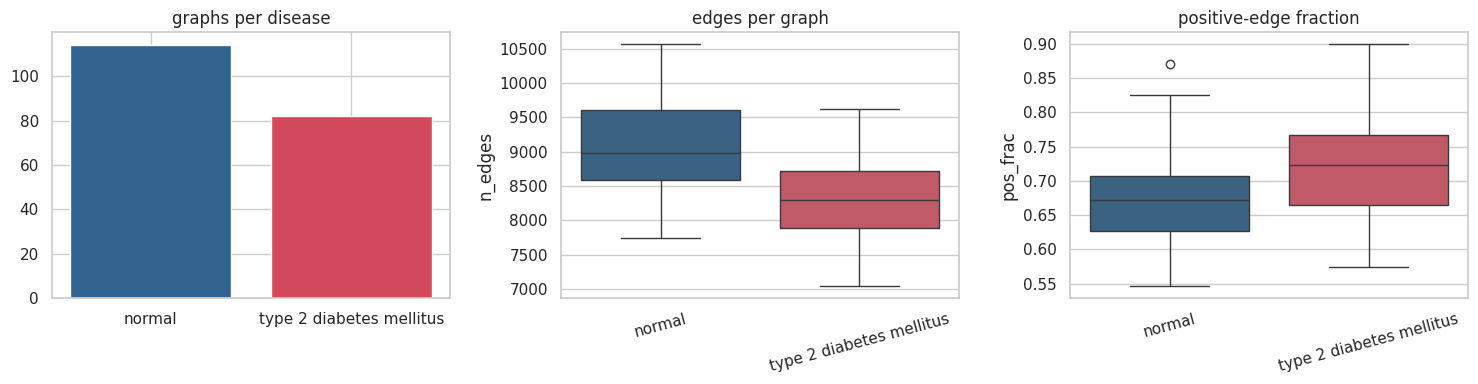

In [12]:
import numpy as np, collections, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

lab_map = {i: l for l, i in
           {l: i for i, l in enumerate(sorted(joint_data["disease"].unique()))}.items()}
y  = np.array([g.y.item() for g in t2d_graphs])
ne = np.array([g.edge_index.shape[1] for g in t2d_graphs])
pos_frac = np.array([(g.edge_type == 0).float().mean().item() for g in t2d_graphs])

print(f"Graphs        : {len(t2d_graphs)}")
print(f"Label counts  : {{ {', '.join(f'{lab_map[k]}: {v}' for k,v in sorted(collections.Counter(y).items()))} }}")
print(f"Nodes / graph : {t2d_graphs[0].x.shape[0]}  |  feature dim: {t2d_graphs[0].x.shape[1]} (1 expr + {EMB_DIM} emb)")
print(f"Directed edges/graph: min {ne.min()}, mean {ne.mean():.0f}, max {ne.max()}")
print(f"Positive-edge fraction: {pos_frac.mean():.1%}")

dfp = pd.DataFrame({"disease": [lab_map[v] for v in y], "n_edges": ne, "pos_frac": pos_frac})
DPAL = {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"}
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(*zip(*sorted(collections.Counter(dfp["disease"]).items())),
          color=[DPAL.get(k, "#888") for k in sorted(collections.Counter(dfp["disease"]))])
ax[0].set_title("graphs per disease")
sns.boxplot(data=dfp, x="disease", y="n_edges", palette=DPAL, ax=ax[1]); ax[1].set_title("edges per graph")
sns.boxplot(data=dfp, x="disease", y="pos_frac", palette=DPAL, ax=ax[2]); ax[2].set_title("positive-edge fraction")
for a in (ax[1], ax[2]): a.set_xlabel(""); a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

> **Result.** The pseudobulk → LIONESS + PPI pipeline yields **196 sample-specific graphs**
> (~1,030 nodes, ~8.8k directed edges each), labelled normal vs T2D — structurally a twin of the
> 303-graph IBD dataset, so the downstream GNN + SAE / GEA steps from `tutorial-ibd.ipynb` apply
> unchanged (set `n_classes=2`). Two things to finish before serious training:
> **(1)** replace the placeholder embeddings with real mouse ESM-2 vectors;
> **(2)** use a **donor-grouped** train/test split — profiles from the same donor across cell
> types must not straddle the split, or performance will be optimistic.